# Sales Revenue Prediction - Amazon Sales Dataset

## Objective
Perform an exploratory data analysis (EDA) on the Amazon sales dataset to understand the distribution and relationships between variables, and identify the key factors that influence total revenue.

## Dataset columns
- `order_id`: unique order identifier
- `order_date`: date the order was placed
- `product_id`: unique product identifier
- `product_category`: product category (Books, Electronics, etc.)
- `price`: original product price
- `discount_percent`: discount percentage applied
- `quantity_sold`: quantity sold
- `customer_region`: customer region
- `payment_method`: payment method used
- `rating`: product rating (1.0 to 5.0)
- `review_count`: number of reviews
- `discounted_price`: price after discount
- `total_revenue`: total revenue generated by the order


## 1. Loading the data

Loading the dataset and displaying the first rows to get a quick overview of its structure.

## 1. Imports and data loading

In [ ]:
import pandas as pd
df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## 2. Dataset structure

`df.info()` shows the number of rows, column names, data types, and whether there are missing values in each column.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


## 3. Statistical summary

`df.describe()` shows descriptive statistics for numeric columns: count, mean, standard deviation, minimum, maximum, and quartiles. This helps identify outliers and understand the data range.

In [ ]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


## 4. Column names

Listing all column names to confirm the available features before analysis.

In [ ]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

## 5. Missing values

Checking how many missing values exist in each column. This is a crucial step before any modeling or analysis, since missing data can lead to errors or biased results.

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


## 6. Data cleaning

Removing rows with missing values to ensure data quality throughout the analysis.

In [ ]:
df = df.dropna()

## 7. Total revenue distribution

The histogram shows how total revenue is distributed across all orders. A right-skewed distribution indicates most orders have lower revenue, with a few high-revenue outliers.

<Axes: xlabel='total_revenue', ylabel='Count'>

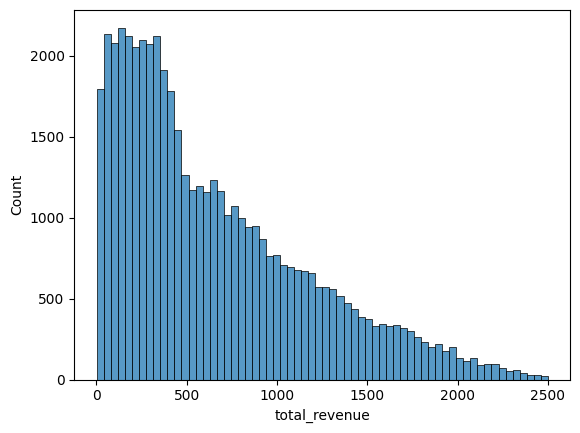

In [ ]:
import seaborn as sns

sns.histplot(df["total_revenue"])

## 8. Quantity sold distribution

The histogram shows how frequently each quantity value (1 to 5) appears in the dataset.

<Axes: xlabel='quantity_sold', ylabel='Count'>

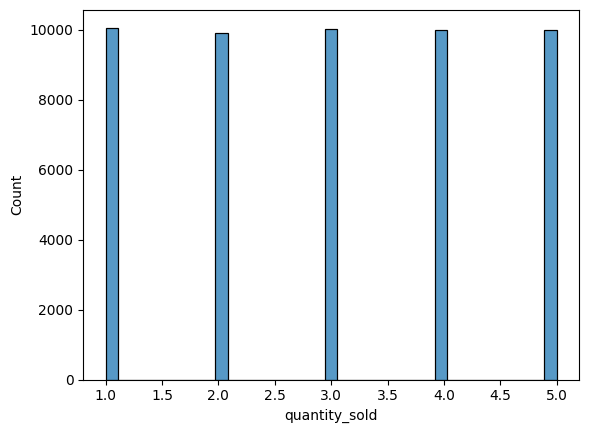

In [ ]:
sns.histplot(df["quantity_sold"])

## 9. Quantity sold value counts

Counting how many orders were placed for each quantity value. A uniform distribution here suggests that quantity is randomly assigned rather than driven by demand patterns.

In [ ]:
df["quantity_sold"].value_counts()

,count
quantity_sold,
1,10060
3,10026
5,10004
4,9996
2,9914


## 10. Quantity sold count plot

A bar chart confirming the distribution of quantity sold values. Each bar represents the number of orders for that quantity.

<Axes: xlabel='quantity_sold', ylabel='count'>

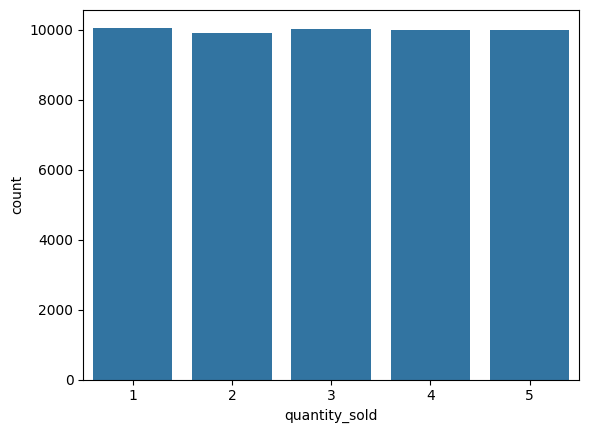

In [ ]:
sns.countplot(x="quantity_sold", data=df)

## 11. Correlation heatmap

The heatmap shows the Pearson correlation between all numeric features. Values close to 1 indicate strong positive correlation, close to -1 indicate strong negative correlation, and close to 0 indicate no linear relationship.

This helps identify which features are most related to `total_revenue` and detect multicollinearity between features.

<Axes: >

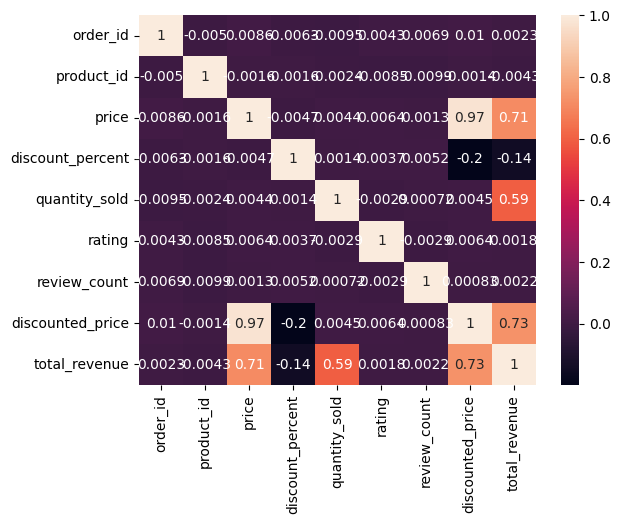

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 12. Total revenue by customer region

The boxplot compares the revenue distribution across different customer regions. The box represents the interquartile range (25th to 75th percentile), the line inside is the median, and the dots are outliers.

<Axes: xlabel='customer_region', ylabel='total_revenue'>

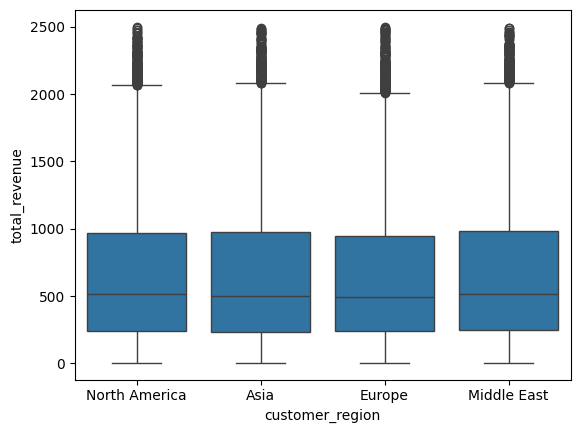

In [ ]:
sns.boxplot(x="customer_region", y="total_revenue", data=df)

## 13. Total revenue by region (without outliers)

The same boxplot with `showfliers=False` removes the outlier dots, making it easier to compare the median and interquartile range across regions without visual distortion.

<Axes: xlabel='customer_region', ylabel='total_revenue'>

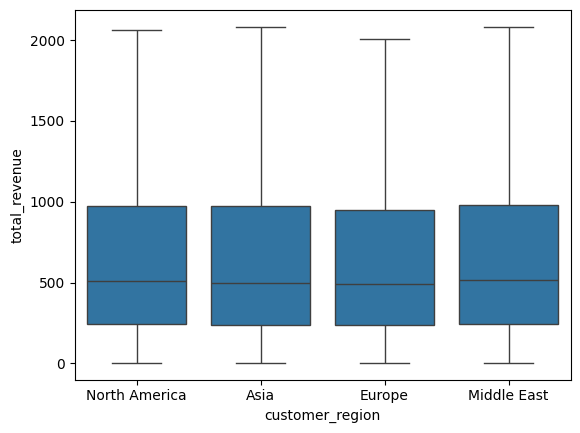

In [ ]:
sns.boxplot(x="customer_region", y="total_revenue", data=df, showfliers=False)

## 14. Discount percentage vs total revenue

The scatter plot shows the relationship between the discount applied and the total revenue generated. If no clear trend is visible, it suggests that discount alone does not strongly predict revenue.

<Axes: xlabel='discount_percent', ylabel='total_revenue'>

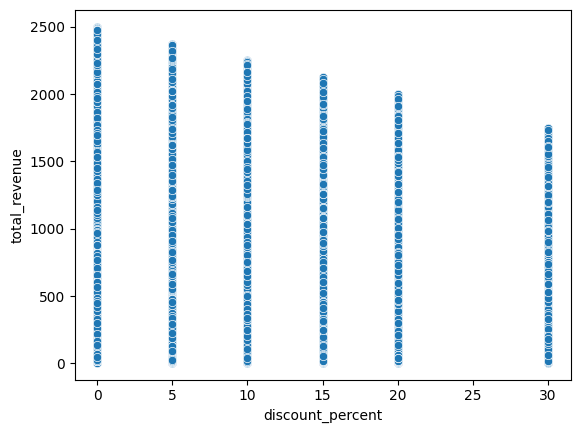

In [ ]:
import seaborn as sns
sns.scatterplot(x="discount_percent", y="total_revenue", data=df)

## 15. Average rating by product category

Grouping orders by product category and computing the average rating for each. This reveals which categories tend to have more satisfied customers.

In [ ]:
df.groupby("product_category")["rating"].mean().sort_values(ascending=False)

,rating
product_category,
Books,3.020259
Sports,2.996891
Home & Kitchen,2.996706
Electronics,2.991298
Fashion,2.987782
Beauty,2.985186


## 16. Top 10 products by review count

Identifying the 10 most reviewed products. Products with many reviews are typically popular and can indicate high-demand items.

In [ ]:
df.sort_values("review_count", ascending=False).head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49302,49303,2023-06-17,2114,Books,332.13,30,2,North America,UPI,4.8,499,232.49,464.98
41899,41900,2023-07-24,2958,Electronics,259.86,5,3,Europe,Cash on Delivery,2.1,499,246.87,740.61
10958,10959,2022-10-23,4125,Electronics,328.22,10,3,Middle East,Credit Card,1.8,499,295.40,886.20
34809,34810,2022-03-17,2170,Sports,108.32,20,4,Middle East,Cash on Delivery,1.2,499,86.66,346.64
33129,33130,2022-09-02,2646,Sports,150.34,10,1,North America,UPI,2.2,499,135.31,135.31
9766,9767,2023-01-31,4411,Electronics,306.43,15,5,Asia,UPI,4.6,499,260.47,1302.35
42765,42766,2023-07-25,1527,Beauty,234.49,10,5,Asia,Credit Card,2.9,499,211.04,1055.20
1202,1203,2023-02-28,4233,Home & Kitchen,220.61,20,2,Asia,UPI,3.4,499,176.49,352.98
41992,41993,2022-03-28,1002,Home & Kitchen,280.81,5,2,Europe,Debit Card,1.7,499,266.77,533.54
19295,19296,2023-09-04,1342,Home & Kitchen,356.85,10,4,Asia,Credit Card,1.7,499,321.17,1284.68


## 17. Average total revenue

Computing the overall mean of `total_revenue` as a baseline reference for model evaluation.

In [ ]:
df["total_revenue"].mean()

np.float64(657.3314748)

## 18. Revenue trend by month

Extracting the month and year from `order_date` to analyze seasonal patterns in revenue. The bar chart shows the average revenue per month, which can reveal peak sales periods.

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.month
df["year"] = df["order_date"].dt.year


<Axes: xlabel='month', ylabel='total_revenue'>

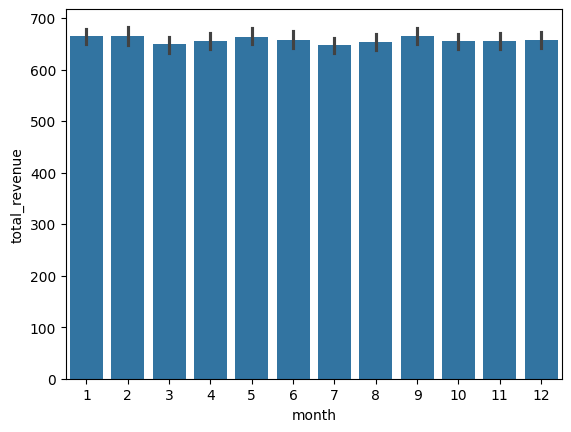

In [ ]:
sns.barplot(x="month", y="total_revenue", data=df)